In [44]:
import schemdraw
import schemdraw.elements as elm
from schemdraw.util import Point

from PIL import Image
import matplotlib.pyplot as plt

import os

In [3]:
def next_name(folder_path):
    # Listar todos os arquivos na pasta que terminam com .png
    png_files = [f for f in os.listdir(folder_path) if f.endswith('.png')]
    
    if not png_files:
        # Se não houver arquivos JPG, o primeiro nome será "1.png"
        return "1.png"
    
    # Remover a extensão e converter para inteiro para ordenar
    numbers = [int(os.path.splitext(f)[0]) for f in png_files]
    
    # Encontrar o maior número e adicionar 1
    next_number = max(numbers) + 1
    
    # Retornar o próximo nome de arquivo
    return f"{next_number}.png"

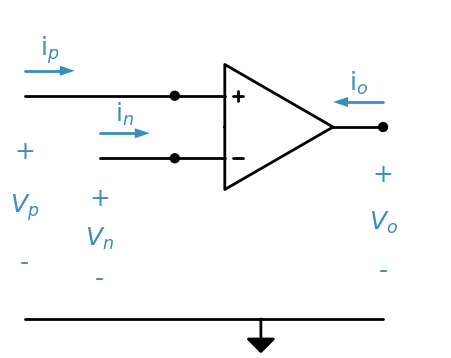

In [ ]:
with schemdraw.Drawing() as d:
    d.config(unit=3, fontsize=18)
    op = elm.Opamp(sign=True)

    li1 = elm.Line().left(1).at((op.in1[0], op.in1[1])).dot()
    li2 = elm.Line().left(1).at((op.in2[0], op.in2[1])).dot()
    lout = elm.Line().right(1).at((op.out[0], op.out[1])).dot()
    lvcc = elm.Line().up(1).at((op.vd[0], op.vd[1])).label('V$^+$', loc='right').dot().color((0,0,0,0))
    lvdd = elm.Line().down(1).at((op.vs[0], op.vs[1])).label('V$^-$', loc='bot').dot().color((0,0,0,0))
    
    # INVERTER ENTRADAS INVERSORA E NÃO INVERSORA
    newpath = [list(p[:]) for p in op.segments[3].path] # criando cópia dos pontos do sinal de +
    for p in newpath:
        p[1] = p[1]*(-1) # modificando os pontos
    op.segments[3].path = newpath # atualizando posição do sinal

    vccmenos = elm.Battery().down(2).label(['-','V$_C$$_C$','+'], loc='top').reverse().dot().color((0,0,0,0))
    elm.GroundSignal(fill=True)

    l1 = elm.Line().left(3).at(li1.end)
    l2 = elm.Line().left(1.5).at(li2.end)

    l3 = elm.Line().left().at(vccmenos.end).tox(l1.end)
    l4 = elm.Line().right().at(vccmenos.end).tox(lout.end)

    vccmais = elm.Battery().up().reverse().toy(lvcc.end).label(['-','V$_C$$_C$','+'], loc='bot').color((0,0,0,0))
    l5 = elm.Line().left().tox(lvcc.end).color((0,0,0,0))

    elm.Gap().at(l1.end).toy(l3.end).label(['+','$V_p$','-']).color('#3b8dbf')
    elm.Gap().at(l2.end).toy(l3.end).label(['+','$V_n$','-']).color('#3b8dbf')
    elm.Gap().at(lout.end).toy(l3.end).label(['+','$V_o$','-']).color('#3b8dbf')

    A1 = elm.CurrentLabel(top=False, length=1, reverse=False, ofst=0).at(l1.end+.5).label('i$_p$', loc='top').theta(0).color('#3b8dbf')
    A2 = elm.CurrentLabel(top=True, length=1, reverse=False, ofst=0).at(l2.end+.5).label('i$_n$', loc='top').theta(0).color('#3b8dbf')
    A3 = elm.CurrentLabel(top=True, length=1, reverse=True, ofst=+1).at(lout.end-.5).label('i$_o$', loc='top').theta(0).color('#3b8dbf')
    
    #d.save(next_name("./"), dpi=600, transparent=True)

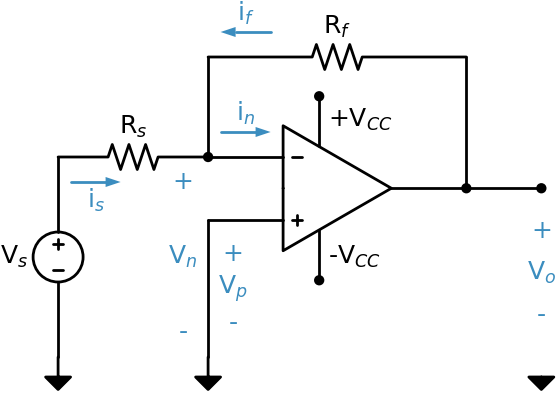

In [90]:
with schemdraw.Drawing() as d:
    d.config(unit=3, fontsize=18)
    op = elm.Opamp(sign=True)

    li1 = elm.Line().left(1.5).at((op.in1[0], op.in1[1])).dot()
    li2 = elm.Line().left(1.5).at((op.in2[0], op.in2[1]))
    lout = elm.Line().right(3).at((op.out[0], op.out[1])).dot()
    
    lvcc = elm.Line().up(1).at((op.vd[0], op.vd[1])).dot().label('+V$_{CC}$', loc='bot')
    lvdd = elm.Line().down(1).at((op.vs[0], op.vs[1])).dot().label('-V$_{CC}$', loc='bot')
    
    ra = elm.Resistor().left().at(li1.end).label('R$_s$')
    va = elm.SourceV().down(4).reverse().label('V$_s$')
    elm.GroundSignal(fill=True)
    elm.Line().up(2).at(li1.end)
    rf = elm.Resistor().right().tox(lout.center).label('R$_f$')
    elm.Line().toy(lout.end).dot()

    vb = elm.Line().down().reverse().at(li2.end).toy(va.end)
    elm.GroundSignal(fill=True)

    elm.Gap().at(lout.end).toy(va.end).label(['+','V$_o$','-']).color('#3b8dbf')
    g = elm.GroundSignal(fill=True)

    g.segments[0].path[0] = (0, -.5)

    elm.Gap().at(li1.end).toy(va.end).label(['+',' ',' ','V$_n$',' ',' ','-'], ofst=(0, -.5)).color('#3b8dbf')
    elm.Gap().at(li2.end).toy(va.end).label(['+','V$_p$','-'], ofst=(0, .5)).color('#3b8dbf')

    A1 = elm.CurrentLabel(top=False, length=1, reverse=False, ofst=0).at(ra.end + Point((.75, -.5))).label('i$_s$', loc='bot').theta(0).color('#3b8dbf')
    A2 = elm.CurrentLabel(top=False, length=1, reverse=False, ofst=0).at(li1.end + Point((.75, .5))).label('i$_n$', loc='top').theta(0).color('#3b8dbf')
    A3 = elm.CurrentLabel(top=False, length=1, reverse=True, ofst=0).at(rf.start + Point((.75, .5))).label('i$_f$', loc='top').theta(0).color('#3b8dbf')

    #d.save(next_name("./"), dpi=600, transparent=True)

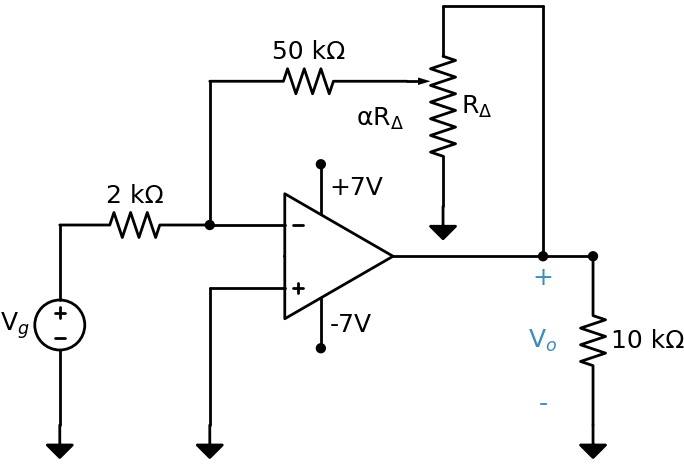

In [ ]:
with schemdraw.Drawing() as d:
    d.config(unit=3, fontsize=18)
    op = elm.Opamp(sign=True)

    li1 = elm.Line().left(1.5).at((op.in1[0], op.in1[1])).dot()
    li2 = elm.Line().left(1.5).at((op.in2[0], op.in2[1]))
    lout = elm.Line().right(4).at((op.out[0], op.out[1])).dot()
    
    lvcc = elm.Line().up(1).at((op.vd[0], op.vd[1])).dot().label('+7V', loc='bot')
    lvdd = elm.Line().down(1).at((op.vs[0], op.vs[1])).dot().label('-7V', loc='bot')
    
    ra = elm.Resistor().left().at(li1.end).label('2 kΩ')
    
    va = elm.SourceV().down(4).reverse().label('V$_g$')
    elm.GroundSignal(fill=True)
    
    elm.Dot().at(lout.center + Point((1,0)))
    l1 = elm.Line().up(5)

    l2 = elm.Line().left(2)
    
    rd = elm.twoterm.PotentiometerIEEE().at(l2.end + Point((0, -2))).up(1).label('R$_Δ$', ofst=(-.5, -.1)).label('αR$_Δ$', ofst=(-.75, 2))
    elm.Line().down(1).at(l2.end)
    elm.Resistor().down(1).at(rd.start)
    elm.Line().down(1)
    elm.GroundSignal(fill=True)
    
    rf = elm.Resistor().at(rd.tap).tox(li1.end).label('50 kΩ')

    elm.Line().down().toy(li1.end)

    vb = elm.Line().down().reverse().at(li2.end).toy(va.end)
    elm.GroundSignal(fill=True)

    elm.Gap().at(l1.start).toy(va.end).label(['+',' ',' ','V$_o$',' ',' ','-']).color('#3b8dbf')
    
    rout = elm.Resistor().down().at(lout.end).toy(va.end).label('10 kΩ', loc='bot')
    
    g = elm.GroundSignal(fill=True)

    #d.save(next_name("./"), dpi=600, transparent=True)

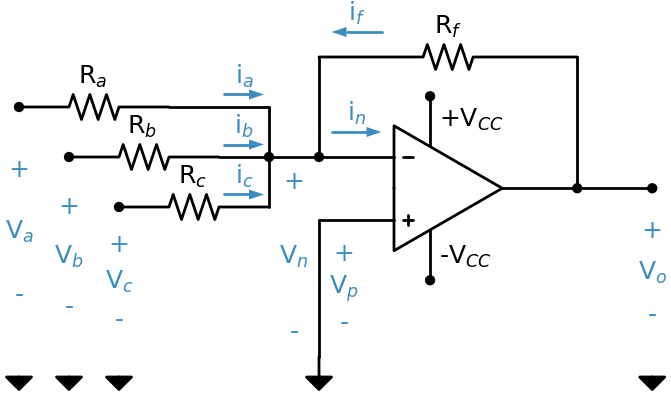

In [ ]:
with schemdraw.Drawing() as d:
    d.config(unit=3, fontsize=18)
    op = elm.Opamp(sign=True)

    li1 = elm.Line().left(1.5).at((op.in1[0], op.in1[1])).dot()
    li2 = elm.Line().left(1.5).at((op.in2[0], op.in2[1]))
    lout = elm.Line().right(3).at((op.out[0], op.out[1])).dot()
    
    lvcc = elm.Line().up(1).at((op.vd[0], op.vd[1])).dot().label('+V$_{CC}$', loc='bot')
    lvdd = elm.Line().down(1).at((op.vs[0], op.vs[1])).dot().label('-V$_{CC}$', loc='bot')
    
    l1 = elm.Line().left(1).at(li1.end).dot()
    
    d.push()
    elm.Line().left(1)
    rb = elm.Resistor().left(3).label('R$_b$').dot()
    gap = elm.Gap().down(4).label(['+','V$_b$','-']).color('#3b8dbf')
    gb = elm.GroundSignal(fill=True)
    gb.segments[0].path[0] = (0, -.5)
    d.pop()
    
    d.push()
    elm.Line().up(1)
    elm.Line().left(2)
    ra = elm.Resistor().left(3).label('R$_a$').dot()
    elm.Gap().toy(gap.end).label(['+','V$_a$','-']).color('#3b8dbf')
    ga = elm.GroundSignal(fill=True)
    ga.segments[0].path[0] = (0, -.5)
    d.pop()
    
    d.push()
    elm.Line().down(1)
    rc = elm.Resistor().left(3).label('R$_c$').dot()
    elm.Gap().toy(gap.end).label(['+','V$_c$','-']).color('#3b8dbf')
    ga = elm.GroundSignal(fill=True)
    ga.segments[0].path[0] = (0, -.5)
    d.pop()
    
    elm.Line().up(2).at(li1.end)
    rf = elm.Resistor().right().tox(lout.center).label('R$_f$')
    elm.Line().toy(lout.end).dot()

    vb = elm.Line().down().reverse().at(li2.end).toy(va.end)
    elm.GroundSignal(fill=True)

    elm.Gap().at(lout.end).toy(va.end).label(['+','V$_o$','-']).color('#3b8dbf')
    g = elm.GroundSignal(fill=True)
    g.segments[0].path[0] = (0, -.5)

    elm.Gap().at(li1.end).toy(va.end).label(['+',' ',' ','V$_n$',' ',' ','-'], ofst=(0, -.5)).color('#3b8dbf')
    elm.Gap().at(li2.end).toy(va.end).label(['+','V$_p$','-'], ofst=(0, .5)).color('#3b8dbf')

    A1 = elm.CurrentLabel(top=False, length=1, reverse=False, ofst=0).at(li1.end + Point((.75, .5))).label('i$_n$', loc='top').theta(0).color('#3b8dbf')
    A2 = elm.CurrentLabel(top=False, length=1, reverse=True, ofst=0).at(rf.start + Point((.75, .5))).label('i$_f$', loc='top').theta(0).color('#3b8dbf')
    
    A3 = elm.CurrentLabel(top=False, length=.8, reverse=False, ofst=0).at(ra.start + Point((+1.5, .25))).label('i$_a$', loc='top').theta(0).color('#3b8dbf')
    A4 = elm.CurrentLabel(top=False, length=.8, reverse=False, ofst=0).at(rb.start + Point((.5, .25))).label('i$_b$', loc='top').theta(0).color('#3b8dbf')
    A5 = elm.CurrentLabel(top=False, length=.8, reverse=False, ofst=0).at(rc.start + Point((-.5, .25))).label('i$_c$', loc='top').theta(0).color('#3b8dbf')

    #d.save(next_name("./"), dpi=600, transparent=True)

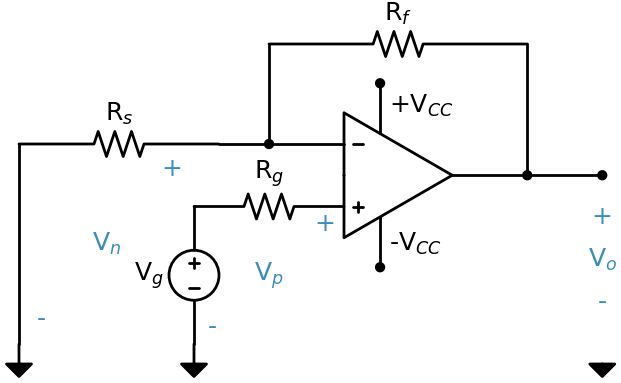

In [ ]:
with schemdraw.Drawing() as d:
    d.config(unit=3, fontsize=18)
    op = elm.Opamp(sign=True)

    li1 = elm.Line().left(1.5).at((op.in1[0], op.in1[1])).dot()
    lout = elm.Line().right(3).at((op.out[0], op.out[1])).dot()
    
    lvcc = elm.Line().up(1).at((op.vd[0], op.vd[1])).dot().label('+V$_{CC}$', loc='bot')
    lvdd = elm.Line().down(1).at((op.vs[0], op.vs[1])).dot().label('-V$_{CC}$', loc='bot')
    
    elm.Line().up(2).at(li1.end)
    rf = elm.Resistor().right().tox(lout.center).label('R$_f$')
    elm.Line().toy(lout.end).dot()

    rg = elm.Resistor().left(3).at(op.in2).label('R$_g$')
    vg = elm.SourceV().down(2.75).reverse().label('V$_g$')
    elm.GroundSignal(fill=True)

    elm.Gap().at(lout.end).toy(vg.end).label(['+','V$_o$','-']).color('#3b8dbf')
    g = elm.GroundSignal(fill=True)
    g.segments[0].path[0] = (0, -.5)

    l1 = elm.Line().left(1).at(li1.end)
    rs = elm.Resistor().left(4).label('R$_s$')
    l2 = elm.Line().toy(vg.end)
    elm.GroundSignal(fill=True)
    elm.Gap().endpoints(l1.center + Point((-1,0)), l2.end).label(['+',' ',' ','V$_n$',' ',' ','-']).color('#3b8dbf')
    elm.Gap().endpoints(rg.start + Point((0,0)), vg.end).label(['+',' ',' ','V$_p$',' ',' ','-']).color('#3b8dbf')
    #d.save(next_name("./"), dpi=600, transparent=True)

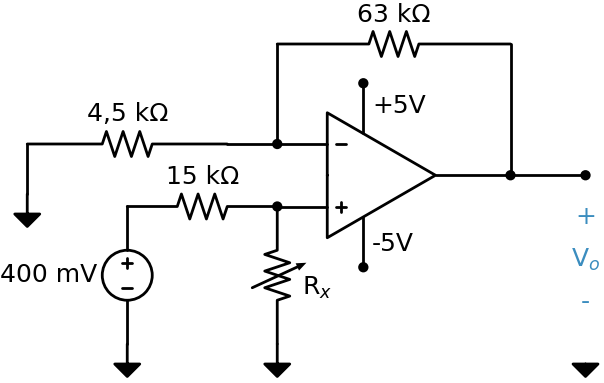

In [ ]:
with schemdraw.Drawing() as d:
    d.config(unit=3, fontsize=18)
    op = elm.Opamp(sign=True)

    li1 = elm.Line().left(1).at((op.in1[0], op.in1[1])).dot()
    li2 = elm.Line().left(1).at((op.in2[0], op.in2[1])).dot()
    lout = elm.Line().right(3).at((op.out[0], op.out[1])).dot()
    
    lvcc = elm.Line().up(1).at((op.vd[0], op.vd[1])).dot().label('+5V', loc='bot')
    lvdd = elm.Line().down(1).at((op.vs[0], op.vs[1])).dot().label('-5V', loc='bot')
    
    elm.Line().up(2).at(li1.end)
    rf = elm.Resistor().right().tox(lout.center).label('63 kΩ')
    elm.Line().toy(lout.end).dot()

    rg = elm.Resistor().left(3).at(li2.end).label('15 kΩ')
    vg = elm.SourceV().down(2.75).reverse().label('400 mV')
    elm.GroundSignal(fill=True)

    rx = elm.twoterm.ResistorVarIEEE().reverse().at(li2.end).toy(vg.end).label('R$_x$', loc='bot', ofst=(.25,-.25))
    elm.GroundSignal(fill=True)

    elm.Gap().at(lout.end).toy(vg.end).label(['+','V$_o$','-']).color('#3b8dbf')
    g = elm.GroundSignal(fill=True)
    g.segments[0].path[0] = (0, -.5)

    l1 = elm.Line().left(1).at(li1.end)
    rs = elm.Resistor().left(4).label('4,5 kΩ')
    l2 = elm.Line().down(1)
    elm.GroundSignal(fill=True)

    
    #d.save(next_name("./"), dpi=600, transparent=True)